In [1521]:
import mujoco
import mediapy as media
import numpy as np
from enviornment_randomizer import Enviornment_Randomizer

In [1522]:

randomizer = Enviornment_Randomizer()
xml= 'xml_models/world.xml'
model = mujoco.MjModel.from_xml_path(xml)

In [1523]:
#getting names
[model.geom(i).name for i in range(model.ngeom)]

['ground_plane',
 '1bottom_l',
 '1top_l',
 '1bottom_r',
 '1top_r',
 '1table_top_geom',
 '1base_geom',
 '1base_plate_geom',
 '1camera_stand_geom',
 'plate_visual_geom',
 'plate_collision_geom',
 'full_slice_slice',
 'deformed_slice_slice',
 'rod_rod',
 'block_block',
 'full_slice_2slice',
 'deformed_slice_2slice',
 'rod_2rod',
 'block_2block']

**RANDOM COLOR TEST**

In [1524]:
model = randomizer.randomize_color_of_single_geom(model=model, geom_name='1table_top_geom')
#creating the data
data = mujoco.MjData(model)
#forwarding the data, we only need lights and positions so we need forward
mujoco.mj_forward(model, data)



""

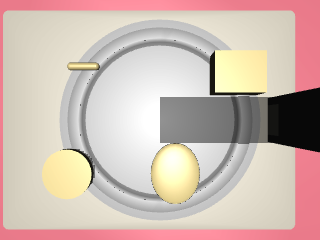

In [1525]:
with mujoco.Renderer(model) as renderer:
    renderer.update_scene(data, camera="emeet_c960_camera")
    image = renderer.render()

media.show_image(image)

**RANDOM NUMBER OF OBJECTS CHECKING**

In [1526]:
body_names = [model.body(i).name for i in range(model.nbody)]
print(body_names)
"""THIS LISTS ALL THE BODIES IN THE SCENE: BUT 3X for FOOD
THERE IS THE PARENT BODY IN WORLD.XML, THE BODY CREATED IN THE FOOD.XML(BC OF ATTACH)
AND THE GEOM BODY CREATED IN THE WORLD.XML (BC OF ATTACH)"""

['world', 'table', '1table', '1bottom left', '1top left', '1bottom right', '1top right', '1table top', 'base_camera_stand_instance', 'plate', 'full_slice_instance', 'full_slice_block', 'deformed_slice_instance', 'deformed_slice_slice', 'rod_instance', 'rod_rod', 'block_instance', 'block_block', 'full_slice_instance_2', 'full_slice_2block', 'deformed_slice_instance_2', 'deformed_slice_2slice', 'rod_instance_2', 'rod_2rod', 'block_instance_2', 'block_2block']


'THIS LISTS ALL THE BODIES IN THE SCENE: BUT 3X for FOOD\nTHERE IS THE PARENT BODY IN WORLD.XML, THE BODY CREATED IN THE FOOD.XML(BC OF ATTACH)\nAND THE GEOM BODY CREATED IN THE WORLD.XML (BC OF ATTACH)'

In [1527]:
list_of_bodies = [
    "full_slice_instance",
    "deformed_slice_instance",
    "rod_instance",
    "block_instance",
    "full_slice_instance_2",
    "deformed_slice_instance_2",
    "rod_instance_2",
    "block_instance_2",
]

list_of_bodies = np.array(list_of_bodies)
model = randomizer.randomize_number_of_objects(list_of_food_object_names=list_of_bodies, 
model=model,min_objects=1, in_secene_z_cord=0.18, out_of_scene_z_cord=-0.18)
model, data = randomizer.reset(model, data)


""

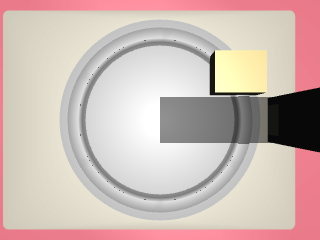

In [1528]:
with mujoco.Renderer(model) as renderer:
    renderer.update_scene(data, camera="emeet_c960_camera")
    image = renderer.render()

media.show_image(image)

""

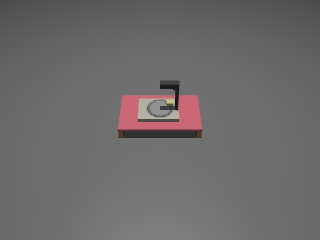

In [1529]:
with mujoco.Renderer(model) as renderer:
    renderer.update_scene(data)
    image = renderer.render()

media.show_image(image)

**RANDOM POSITION**

In [1530]:
list_of_bodies = [
    "full_slice_instance",
    "deformed_slice_instance",
    "rod_instance",
    "block_instance",
    "full_slice_instance_2",
    "deformed_slice_instance_2",
    "rod_instance_2",
    "block_instance_2",
]
#KEEPING DEFAULT PLATE
model = randomizer.randomize_position_of_objects(list_of_food_object_names=list_of_bodies, 
model=model)
model, data = randomizer.reset(model, data)


""

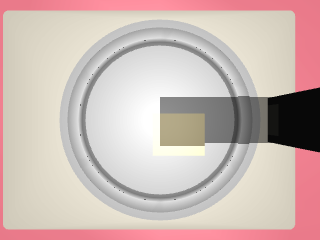

In [1531]:
with mujoco.Renderer(model) as renderer:
    renderer.update_scene(data, camera="emeet_c960_camera")
    image = renderer.render()

media.show_image(image)

**RANDOMIZE COLOR OF OBJECTS**

In [1532]:
randomizer.randomize_color_of_multiple_bodies_with_single_geom(model, list_of_body_names=list_of_bodies)
model, data = randomizer.reset(model, data)


""

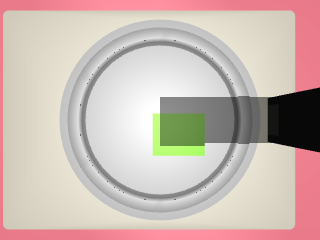

In [1533]:
with mujoco.Renderer(model) as renderer:
    renderer.update_scene(data, camera="emeet_c960_camera")
    image = renderer.render()

media.show_image(image)

**Randomize color of everything else**

In [1534]:
[model.geom(i).name for i in range(model.ngeom)]

['ground_plane',
 '1bottom_l',
 '1top_l',
 '1bottom_r',
 '1top_r',
 '1table_top_geom',
 '1base_geom',
 '1base_plate_geom',
 '1camera_stand_geom',
 'plate_visual_geom',
 'plate_collision_geom',
 'full_slice_slice',
 'deformed_slice_slice',
 'rod_rod',
 'block_block',
 'full_slice_2slice',
 'deformed_slice_2slice',
 'rod_2rod',
 'block_2block']

In [1535]:
#randomizing color of camera_stand geom and ground_plate and plate visual_geom 
model = randomizer.randomize_color_of_multiple_bodies_with_multiple_geom(
    model=model,
    list_of_body_names=[
        "base_camera_stand_instance",
        "plate"
    ],
)
# Randomize the plate using white, ivory, cream, and light-yellow shades.
# model = randomizer.randomize_plate_color(model=model, plate_geom_name="plate_visual_geom")

model, data = randomizer.reset(model, data)

""

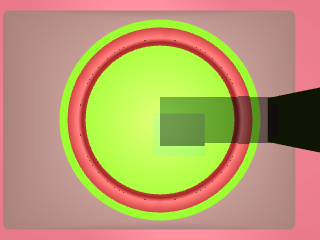

In [1536]:
with mujoco.Renderer(model) as renderer:
    renderer.update_scene(data, camera="emeet_c960_camera")
    image = renderer.render()

media.show_image(image)

In [1537]:
"""FOUND PLATE GEOM"""
# model = randomizer.randomize_color_of_single_geom(model=model, geom_name='1base_plate_geom')
# model, data = randomizer.reset(model, data)
# with mujoco.Renderer(model) as renderer:
#     renderer.update_scene(data, camera="emeet_c960_camera")
#     image = renderer.render()

# media.show_image(image)

'FOUND PLATE GEOM'

In [1538]:
randomizer.visibility_check(model, list_of_body_names=list_of_bodies,plate_geom="1base_plate_geom")
model, data = randomizer.reset(model, data)

""

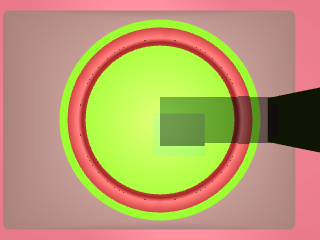

In [1539]:
with mujoco.Renderer(model) as renderer:
    renderer.update_scene(data, camera="emeet_c960_camera")
    image = renderer.render()

media.show_image(image)

In [1540]:
randomizer.randomize_camera_position(
    model,
    camera_name="emeet_c960_camera",
    offset_bounds=[[-0.11, 0.05], [-0.03, 0.03], [-0.10, -0.05]],
)

""

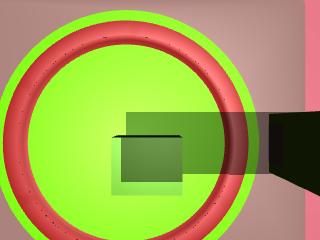

In [1541]:
model, data = randomizer.reset(model, data)
with mujoco.Renderer(model) as renderer:
    renderer.update_scene(data, camera="emeet_c960_camera")
    image = renderer.render()

media.show_image(image)

In [1542]:
camera = model.camera("emeet_c960_camera")
original_position = camera.pos.copy()
print(original_position)

[0.0349045  0.02373139 0.41815704]


**LIGHT RANDOMIZATION**

In [1543]:
#getting the light_names
name_of_lights = [model.light(i).name for i in range(model.nlight)]
name_of_lights = np.array(name_of_lights)

In [ ]:
x_offset_range, y_offset_range, z_offset_range = np.array([-2, 2]), np.array([-2, 2]), np.array([1, 10])
randomizer.randomize_lighting(model,min_number_of_lights=1,max_number_of_lights=3, 
                              x_offset_range= x_offset_range, y_offset_range= y_offset_range,z_offset_range= z_offset_range)
model, data = randomizer.reset(model=model, data=data)

""

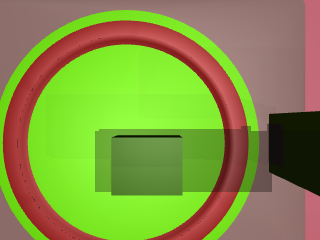

In [1545]:
model, data = randomizer.reset(model, data)
with mujoco.Renderer(model) as renderer:
    renderer.update_scene(data, camera="emeet_c960_camera")
    image = renderer.render()

media.show_image(image)

In [1547]:
for i in range(model.nlight):
    light = model.light(i)

    if light.active[0] == 1:
        print(
            f"Light {i} ({light.name}): "
            f"x={light.pos[0]:.3f}, "
            f"y={light.pos[1]:.3f}, "
            f"z={light.pos[2]:.3f}"
        )

Light 0 (light_1): x=0.205, y=-1.670, z=1.756
Light 1 (light_2): x=-0.272, y=-1.138, z=5.835
Light 2 (light_3): x=1.472, y=-0.327, z=6.168
Light 3 (light_4): x=0.977, y=0.574, z=9.850
